<a href="https://colab.research.google.com/github/An4PDM/preco-imoveis-ml-preditivo/blob/main/tratamento_dados_imoveis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Etapa 1. Tratamento de dados**

Será usado um conjunto de dados para de Imóveis, onde o modelo deverá prever o preço de um imovel com base nos dados fornecidos.


Link do dataset: https://www.kaggle.com/datasets/pedrobelle/dataset-imoveis



A seguir, estão algumas perguntas a serem respondidas na etapa inicial de exploração do dataset:

- Quais são as colunas?
- Quantas linhas e colunas existem?
- Qual é o tipo de cada variável?
- Existem valores nulos?
- Existem valores duplicados?
- Quais são as estatísticas básicas?
- Existem valores muito fora do padrão (outliers)?
- Qual variável será o nosso target?
- Existem colunas que precisam ser transformadas?

In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
from google.colab import files
import matplotlib.pyplot as plt

In [2]:
# Salvando o arquivo csv
uploaded = files.upload()

Saving dataset_imoveis.csv to dataset_imoveis.csv


In [4]:
df = pd.read_csv('dataset_imoveis.csv')
df.head(5)

,Preço,Área (m²),Quartos,Banheiros,Garagem,Localização
0,271958,288,4,1,1,Subúrbio
1,821155,86,2,3,1,Zona Sul
2,281932,160,4,1,0,Centro
3,515838,253,1,3,2,Zona Sul
4,409178,278,1,1,0,Subúrbio


Variáveis numéricas: Preço, Área (m²), Quartos, Banheiros, Garagem.

Variáveis Categóricas: Localização.

Target -> Preço

In [5]:
# Quantidade de linhas e colunas
df.shape # 1000 linhas e 6 colunas

(1000, 6)

In [ ]:
# Informações gerais sobre as colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Preço        1000 non-null   int64 
 1   Área (m²)    1000 non-null   int64 
 2   Quartos      1000 non-null   int64 
 3   Banheiros    1000 non-null   int64 
 4   Garagem      1000 non-null   int64 
 5   Localização  1000 non-null   object
dtypes: int64(5), object(1)
memory usage: 47.0+ KB


In [ ]:
# Medidas estatísticas das colunas numéricas
df.describe()

,Preço,Área (m²),Quartos,Banheiros,Garagem
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,559705.091000,164.675000,2.531000,1.978000,0.995000
std,245359.571981,74.802465,1.136808,0.830786,0.828046
min,150404.000000,40.000000,1.000000,1.000000,0.000000
25%,342370.000000,100.000000,2.000000,1.000000,0.000000
50%,550341.000000,165.500000,2.500000,2.000000,1.000000
75%,777520.750000,227.000000,4.000000,3.000000,2.000000
max,994573.000000,299.000000,4.000000,3.000000,2.000000


**Preço**: A média 559.705 está bem próxima da mediana (50%) 550.341, o que pode indicar homogeneidade dos dados, sem valores extremos.

In [ ]:
# Verificação de valores nulos
df.isnull().sum()

,0
Preço,0
Área (m²),0
Quartos,0
Banheiros,0
Garagem,0
Localização,0


Não existem valores nulos, então nao será necessário tratar dados faltantes.

In [ ]:
# Verificação de valores duplicados
df.duplicated().sum()

np.int64(0)

 **Insights iniciais**

A partir da análise inicial, foi possível observar que os dados aparentam estar bem estruturados e não apresentam, à primeira vista, problemas significativos de qualidade. Não foram identificados valores ausentes ou inconsistências evidentes nas variáveis analisadas. Além disso, os valores apresentados pelas variáveis parecem estar dentro de intervalos plausíveis e não foram observados valores extremos de forma evidente nesta primeira análise.

As variáveis disponíveis também apresentam características que podem ser relevantes para a previsão do preço dos imóveis. Como o objetivo do projeto é prever o preço de um imóvel, essa variável será utilizada como **target**, enquanto as demais características serão consideradas inicialmente como possíveis **features**.

Apesar dessas primeiras observações, a análise realizada até o momento é apenas uma **avaliação inicial**. A etapa de Análise Exploratória dos Dados (EDA) será importante para investigar mais profundamente a distribuição das variáveis, possíveis outliers, correlações e relações entre as características dos imóveis e seus preços.


#### **Análise Exploratória**
Antes de alterar os dados, devemos visualizar e entender o conjunto, aplicando estatística descritiva (média, mediana, limites) e gráficos para identificação de outliers.

Vamos dividir a EDA em 4 partes:
1. Distribuição das variáveis;
2. Análise do target (preço);
3. Relação entre as features e o preço;
4. Correlação entre as variáveis.

**1. Distribuição de Variáveis**

A análise de distribuição de variáveis é essencialmente importante para identificar possíveis outliers, ruídos nos dados ou até mesmo se há necessidade de padronização/normalização para o caso de os dados estarem com medidas muito discrepantes.

Podemos utilizar histogramas para facilitar a visualização da distribuição:

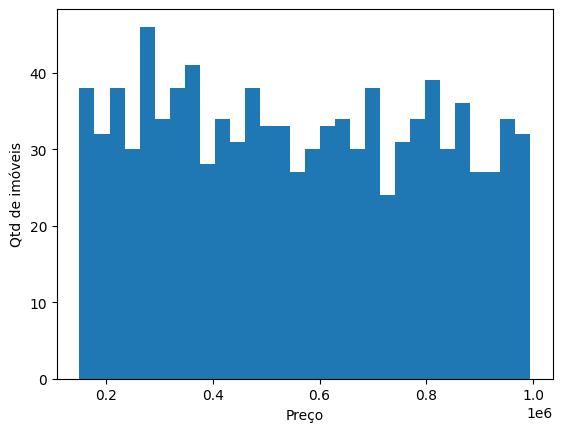

In [12]:
# Distribuição do Preço (nosso target)
plt.hist(df['Preço'], bins=30) # bins=30 define o intervalo utilizado

plt.xlabel('Preço')
plt.ylabel('Qtd de imóveis')
plt.show()

Analisando o histograma acima, percebe-se que não há uma diferença muito grande no preço dos imóveis em relação a quantidade.

Abaixo, foi gerado um boxplot para identificar possíveis outiliers no nosso target Preço: não foi identificado nenhum possível outlier.

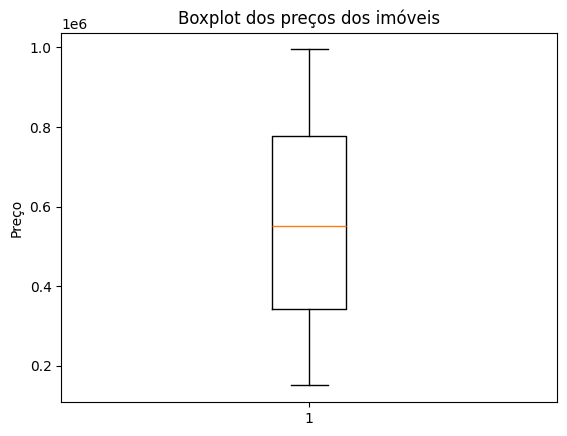

In [14]:
plt.boxplot(df["Preço"])

plt.ylabel("Preço")
plt.title("Boxplot dos preços dos imóveis")

plt.show()

#### **Limpeza de dados**
**Tratamento de Valores Ausentes (Missing Values):** Caso existam registros com campos em branco, há três condutas:
 - Remover os registros: Eliminar as linhas que possuem informações ausentes;
 - Remover o atributo: Excluir a coluna inteira se a quantidade de falhas for elevada;
 - Imputação: Preencher as lacunas com uma estimativa estatística (como a média ou a mediana calculada sobre os dados conhecidos).

**Tratamento de Inconsistências e Outliers:** Identifique e trate erros de digitação (como valores negativos em Tamanho_M2 ou anos impossíveis) e avalie o impacto de observações extremamente discrepantes (outliers) no modelo.

#### **Codificação de Variáveis Categóricas (Feature Encoding)**

Algoritmos de ML realizam cálculos matemáticos e exigem que todos os dados de entrada estejam em formato numérico:
 - One-Hot Encoding: Para variáveis categóricas sem hierarquia (como Bairro), cria-se uma nova coluna binária para cada categoria possível, marcando 1 quando a categoria estiver presente e 0 quando ausente.

 - Mapeamento Ordinal: Se a categoria apresentar uma ordem lógica (ex: "pequeno", "médio", "grande"), atribua números inteiros sequenciais preservando essa ordenação.

#### **Escalonamento de Características (Feature Scaling)**

Quando variáveis possuem escalas com ordens de grandeza muito distintas (ex: Tamanho_M2 variando de 30 a 500 e Quartos variando de 1 a 5), os atributos de maior escala podem dominar os cálculos do algoritmo. Existem dois métodos principais para equalizar as escalas:
 - **Padronização (Escore Z):** Subtrai a média e divide pelo desvio-padrão de cada variável. Isso gera dados com média 0 e variância 1, sendo uma técnica menos sensível a outliers;
 - **Normalização (Escala Min-Max):** Redimensiona os valores para que fiquem estritamente dentro de um intervalo fixo (geralmente entre 0 e 1).

#### **Engenharia de Características (Feature Engineering)**

A criação de novas variáveis combinando colunas existentes costuma aumentar o poder preditivo dos modelos.
Exemplo: Em vez de usar apenas a contagem bruta de cômodos, pode-se criar o atributo derivado Metros_por_Quarto (Tamanho_M2 dividido por Quartos), fornecendo uma métrica muito mais informativa sobre o padrão do imóvel.

#### **Divisão entre Treino e Teste (Train/Test Split)**

Para evitar o **sobreajuste (overfitting)**, fenômeno em que o modelo decora o conjunto de dados atual, mas falha em prever novos exemplos, é necessário separar os dados antes de treinar o algoritmo.
Separe uma fração do conjunto de dados (por exemplo, 20% a 30%) para formar o conjunto de teste e mantenha o restante como conjunto de treinamento.

Regra de Ouro: Todas as transformações (como o cálculo da mediana para preencher nulos ou a média para o escalonamento) devem ser calculadas apenas no conjunto de treinamento e aplicadas posteriormente no conjunto de teste para evitar o vazamento de informações do teste para o modelo.